# ╔════════════════════════════════════════════════════════════╗
# ║ 🍄 きのこ　🍄
# ╚════════════════════════════════════════════════════════════╝


# ===================== IMPORTS ======================

In [44]:
# ═════════════════════ LOAD ═════════════════════
from pathlib import Path
import os

# ═════════════════════ SECTION ═════════════════════
import pandas as pd
import numpy as np

# ═════════════════════ VISUALIZATION TOOLS ═════════════════════
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# ═════════════════════ CNN ═════════════════════
from tensorflow.keras import Sequential, layers, optimizers, callbacks, regularizers
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.metrics import AUC
import tensorflow as tf

# ═════════════════════ OTHER ═════════════════════
from datetime import datetime
from tensorflow.keras.preprocessing.image import load_img, save_img, img_to_array

# ===================== PREPROCESSING ======================

In [45]:
# # ░░░░░░░░░░░░░░ DATA AUGMENTATION (edible) ░░░░░░░░░░░░░░

# def augment_edible(edible_dir="data/image_dataset/edible"):
#     paths = list(Path(edible_dir).rglob("*.png"))

#     for p in paths:
#         save_img(str(p.parent / f"aug_{p.name}"), np.fliplr(img_to_array(load_img(p))))

# augment_edible()

# DO NOT RUN

In [46]:
print(f"🍄 Edible: {len(list(Path('data/image_dataset/edible').rglob('*.jpg')) + list(Path('data/image_dataset/edible').rglob('*.png')))}")
print(f"☠️ Poisonous: {len(list(Path('data/image_dataset/poisonous').rglob('*.jpg')) + list(Path('data/image_dataset/poisonous').rglob('*.png')))}")

🍄 Edible: 4950
☠️ Poisonous: 5497


# =====================[■■■■■■■■■□] 90% LOADING ======================


In [47]:
paths = list(Path("data/image_dataset/").rglob("*.png"))
df = pd.DataFrame({
    "path": paths,
    "label": [p.parent.name for p in paths]
})

# ===================== CONFIGURATION ======================

In [48]:
# ░░ 💾 Save best model ░░
timestamp = datetime.now().strftime("%d%m%Y_%H%M%S")
os.makedirs("models", exist_ok=True)
MODEL_1 = "models/model_1.keras"
MODEL_2 = "models/augmented_1.keras"


# ░░ 🏋 Training history logs ░░
os.makedirs("logs", exist_ok=True)
csv_logger_1 = CSVLogger(f"logs/baseline_history_{timestamp}.csv")
csv_logger_2 = CSVLogger(f"logs/augmented_history_{timestamp}.csv")

# ===================== MODEL BASELINE ======================

In [49]:
def initialize_baseline_model():
    baseline = Sequential([
        layers.Input(shape=(128, 128,3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(512, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])

    return baseline


In [50]:
baseline = initialize_baseline_model()
baseline.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_11 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,881,761 (18.62 MB)

 Trainable params: 4,880,289 (18.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [51]:
# ░░░░░░░░░░░░░░ Compilation ░░░░░░░░░░░░░░

def compile_baseline_model(baseline):
    adam = optimizers.Adam(learning_rate = 1e-4)
    baseline.compile(
        loss = "binary_crossentropy",
        optimizer=adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )

    return baseline

In [57]:
dataset_dir = os.path.abspath("data/image_dataset")

# ░░░░░░░░░░░░░░ Define data ░░░░░░░░░░░░░░
batch_size = 32

# We define a first one for the train data
train_ds = image_dataset_from_directory(
    dataset_dir,
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "training",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size)

# We define a second one for the test data
val_ds = image_dataset_from_directory(
    dataset_dir,
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "validation",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size)

Found 10447 files belonging to 2 classes.
Using 8358 files for training.
Found 10447 files belonging to 2 classes.
Using 2089 files for validation.


In [58]:
# ░░░░░░░░░░░░░░ Inspect binary classification configuration ░░░░░░░░░░░░░░
class_names = train_ds.class_names
print(class_names)

['edible', 'poisonous']


In [59]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
baseline = initialize_baseline_model()
baseline = compile_baseline_model(baseline)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_1,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=3,
                                        verbose=1,
                                        min_lr=1e-6)

history = baseline.fit(
    train_ds,
    batch_size=32,
    epochs=10,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint, csv_logger_1],
    verbose = 1
)

Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 41s 152ms/step - accuracy: 0.5782 - auc: 0.6072 - loss: 0.7427 - precision: 0.5884 - recall: 0.6688 - val_accuracy: 0.5199 - val_auc: 0.5214 - val_loss: 1.3826 - val_precision: 0.5199 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 41s 158ms/step - accuracy: 0.6250 - auc: 0.6784 - loss: 0.6413 - precision: 0.6397 - recall: 0.6629 - val_accuracy: 0.6127 - val_auc: 0.6627 - val_loss: 0.6559 - val_precision: 0.6205 - val_recall: 0.6565 - learning_rate: 1.0000e-04
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 41s 157ms/step - accuracy: 0.6527 - auc: 0.7233 - loss: 0.6064 - precision: 0.6667 - recall: 0.6835 - val_accuracy: 0.6587 - val_auc: 0.7170 - val_loss: 0.6111 - val_precision: 0.6615 - val_recall: 0.7035 - learning_rate: 1.0000e-04
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 43s 165ms/step - accuracy: 0.6859 - auc: 0.7582 - loss: 0.5829 - precision: 0.6989 - recall: 0.7114 - val_accuracy: 0.6673 - val_auc: 0.7335 

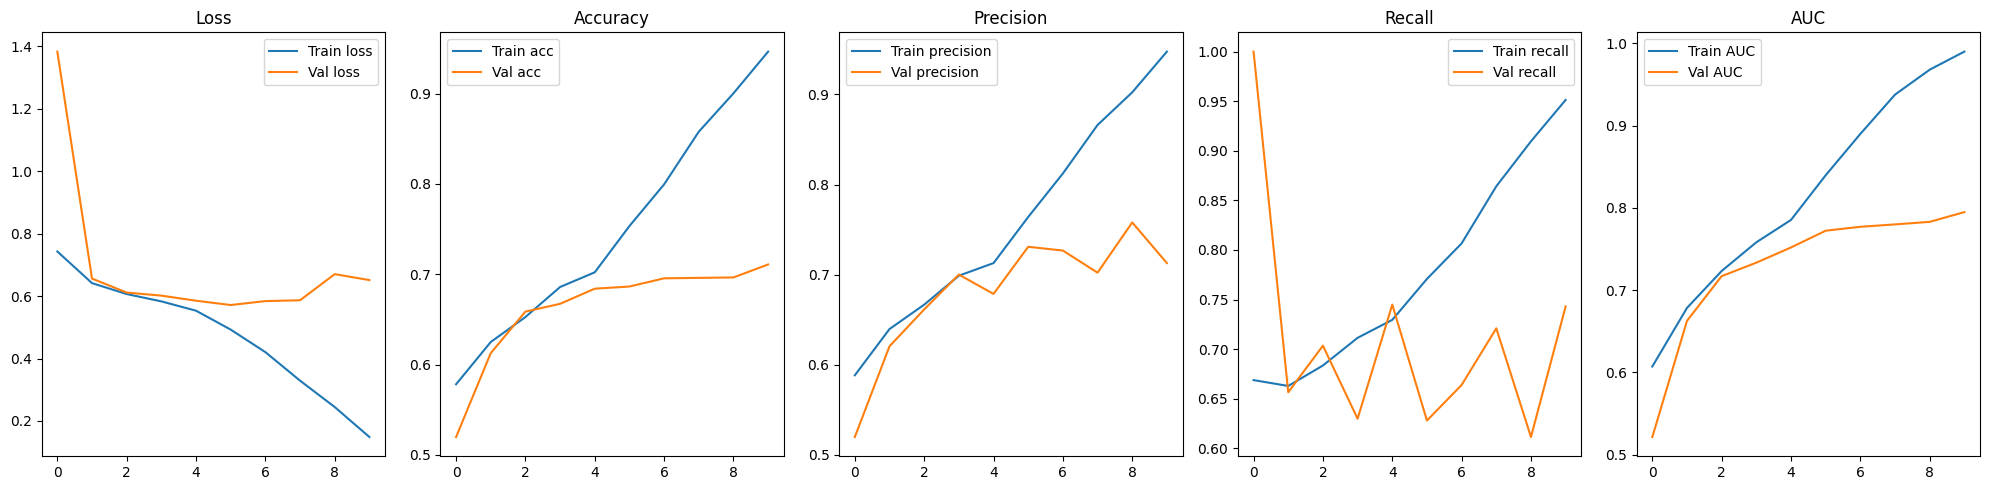

In [60]:
def plot_history(history):
    fig, ax = plt.subplots(1, 5, figsize=(20, 5))

    # ░░ Row 1 : Train & Val Loss ░░
    ax[0].set_title('Loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Val loss")

    # ░░ Row 1 : Train & Val Accuracy ░░
    ax[1].set_title('Accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Val acc")

    # ░░ Row 1 : Train & Val Precision ░░
    ax[2].set_title('Precision')
    ax[2].plot(history.epoch, history.history["precision"], label="Train precision")
    ax[2].plot(history.epoch, history.history["val_precision"], label="Val precision")

    # ░░ Row 1 : Train & Val Recall ░░
    ax[3].set_title('Recall')
    ax[3].plot(history.epoch, history.history["recall"], label="Train recall")
    ax[3].plot(history.epoch, history.history["val_recall"], label="Val recall")

    # ░░ Row 1 : Train & Val AUC ░░
    ax[4].set_title('AUC')
    ax[4].plot(history.epoch, history.history["auc"], label="Train AUC")
    ax[4].plot(history.epoch, history.history["val_auc"], label="Val AUC")

    for a in ax:
        a.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [62]:
# Loss, Accuracy, Precision, Recall, AUC
baseline.evaluate(val_ds)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6865 - auc: 0.7723 - loss: 0.5712 - precision: 0.7310 - recall: 0.6280


[0.5711976289749146,
 0.6864528656005859,
 0.730975329875946,
 0.6279926300048828,
 0.7723160982131958]

# ===================== MODEL BASELINE + DATA AUGMENTATION ======================

In [63]:
def initialize_augmented_model():
    augmented = Sequential([
        layers.Input(shape=(128,128,3)),
        layers.Rescaling(1./255),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(256, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        layers.Dropout(0.4),

        layers.Dense(1, activation="sigmoid")
    ])
    return augmented

In [64]:
augmented = initialize_augmented_model()
augmented.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,033 (1.62 MB)

 Trainable params: 423,073 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [65]:
def compile_augmented_model(augmented):
    adam = optimizers.Adam(learning_rate = 1e-4)

    augmented.compile(
        loss = "binary_crossentropy",
        optimizer = adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )
    return augmented

In [66]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
augmented = initialize_augmented_model()
augmented = compile_augmented_model(augmented)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_2,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=5,
                                        verbose=1,
                                        min_lr=1e-6)
history_2 = augmented.fit(
    train_ds,
    batch_size=32,
    epochs=10,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint,csv_logger_2],
    verbose = 1
)

Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 33s 121ms/step - accuracy: 0.5938 - auc: 0.6276 - loss: 0.6887 - precision: 0.6050 - recall: 0.6638 - val_accuracy: 0.4581 - val_auc: 0.4374 - val_loss: 0.8492 - val_precision: 0.0741 - val_recall: 0.0037 - learning_rate: 1.0000e-04
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 32s 123ms/step - accuracy: 0.6207 - auc: 0.6702 - loss: 0.6506 - precision: 0.6284 - recall: 0.6883 - val_accuracy: 0.5663 - val_auc: 0.6003 - val_loss: 0.6918 - val_precision: 0.5562 - val_recall: 0.8195 - learning_rate: 1.0000e-04
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 33s 125ms/step - accuracy: 0.6336 - auc: 0.6849 - loss: 0.6396 - precision: 0.6434 - recall: 0.6860 - val_accuracy: 0.5644 - val_auc: 0.6680 - val_loss: 0.8035 - val_precision: 0.5452 - val_recall: 0.9770 - learning_rate: 1.0000e-04
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 33s 127ms/step - accuracy: 0.6448 - auc: 0.6963 - loss: 0.6320 - precision: 0.6539 - recall: 0.6944 - val_accuracy: 0.5979 - val_auc: 0.6911 

In [67]:
def plot_history(history, history_2):
    fig, ax = plt.subplots(6, 1, figsize=(12, 24))

    # ░░ Row 1 : Train loss ░░
    ax[0].set_title('Train Loss Comparison')
    ax[0].plot(history.epoch, history.history["loss"], label="Baseline")
    ax[0].plot(history_2.epoch, history_2.history["loss"], label="Augmented", color="red")
    ax[0].legend()

    # ░░ Row 2 : Val loss ░░
    ax[1].set_title('Validation Loss Comparison')
    ax[1].plot(history.epoch, history.history["val_loss"], label="Baseline")
    ax[1].plot(history_2.epoch, history_2.history["val_loss"], label="Augmented", color="red")
    ax[1].legend()

    # ░░ Row 3 : Train Accuracy ░░
    ax[2].set_title('Train Accuracy Comparison')
    ax[2].plot(history.epoch, history.history["accuracy"], label="Baseline")
    ax[2].plot(history_2.epoch, history_2.history["accuracy"], label="Augmented", color="red")
    ax[2].legend()

    # ░░ Row 4 : Val Accuracy ░░
    ax[3].set_title('Validation Accuracy Comparison')
    ax[3].plot(history.epoch, history.history["val_accuracy"], label="Baseline")
    ax[3].plot(history_2.epoch, history_2.history["val_accuracy"], label="Augmented", color="red")
    ax[3].legend()

    # ░░ Row 5 : Train AUC ░░
    ax[4].set_title('Train AUC Comparison')
    ax[4].plot(history.epoch, history.history["auc"], label="Baseline")
    ax[4].plot(history_2.epoch, history_2.history["auc"], label="Augmented", color="red")
    ax[4].legend()

    # ░░ Row 6 : Val AUC ░░
    ax[5].set_title('Validation AUC Comparison')
    ax[5].plot(history.epoch, history.history["val_auc"], label="Baseline")
    ax[5].plot(history_2.epoch, history_2.history["val_auc"], label="Augmented", color="red")
    ax[5].legend()

    plt.tight_layout()
    plt.show()

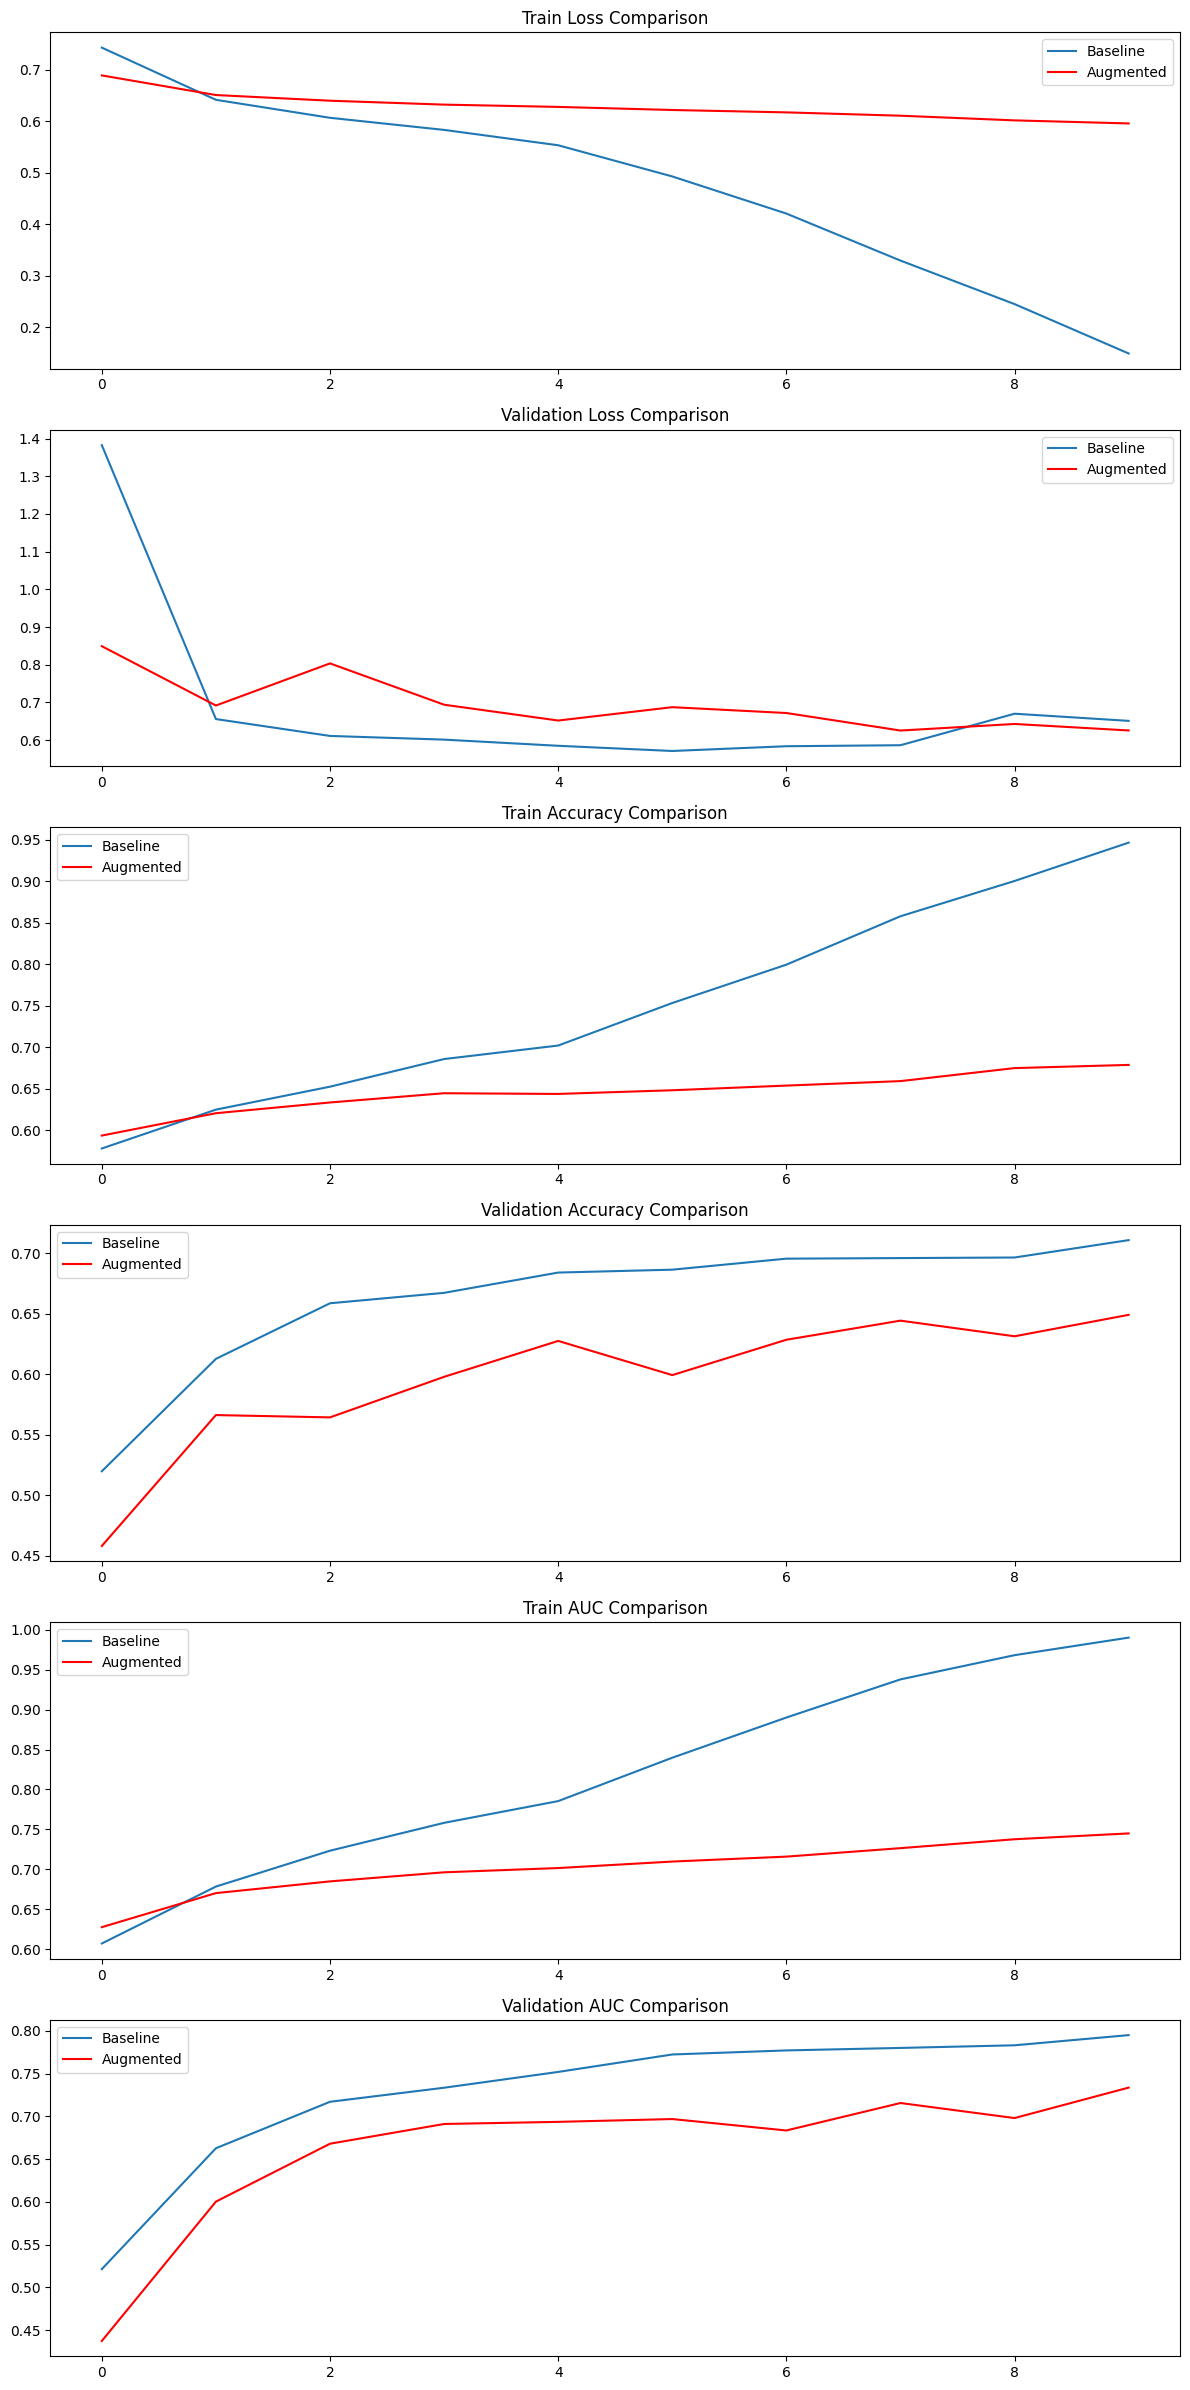

In [68]:
plot_history(history, history_2)

In [72]:
display(baseline.evaluate(val_ds), augmented.evaluate(val_ds))

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6865 - auc: 0.7723 - loss: 0.5712 - precision: 0.7310 - recall: 0.6280
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6443 - auc: 0.7156 - loss: 0.6255 - precision: 0.6292 - recall: 0.7689


[0.571197509765625,
 0.6864528656005859,
 0.730975329875946,
 0.6279926300048828,
 0.7723160982131958]

[0.6254684329032898,
 0.6443274021148682,
 0.6292389035224915,
 0.7688766121864319,
 0.7155761122703552]

In [73]:
# ░░ 🔮 Prediction ░░

# preds_base = probability that the image belongs to class 1
preds_base = baseline.predict(val_ds, verbose=0)

# preds_aug = probability that the image belongs to class 1
preds_augm = augmented.predict(val_ds, verbose=0)

df_prediction = pd.DataFrame({
    "Baseline": preds_base.flatten(),
    "Augmented": preds_augm.flatten(),
})

display(df_prediction.head(10))

,Baseline,Augmented
0,0.438233,0.523491
1,0.777907,0.510472
2,0.819763,0.916822
3,0.490131,0.781934
4,0.368921,0.798222
5,0.914810,0.788692
6,0.777478,0.319791
7,0.306438,0.652063
8,0.359519,0.719561
9,0.780471,0.409832


In [74]:
# ░░ 🔮 Prediction Label 1 ░░
# if > 0.5 → 1 else → 0

# Convert baseline predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels = (preds_base > 0.5).astype(int)

# Convert augmented baseline predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels_2 = (preds_augm > 0.5).astype(int)

display(pred_labels, pred_labels_2)

array([[0],
       [1],
       [1],
       ...,
       [0],
       [1],
       [0]], shape=(2089, 1))

array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]], shape=(2089, 1))

In [75]:
# ░░ 🎨  Let's have something prettier ░░

df_proba_results = pd.DataFrame({
    "Baseline_proba": preds_base.flatten(),
    "Augmented_proba": preds_augm.flatten(),
})

class_map = dict(enumerate(class_names))

df_proba_results["Baseline_label"] = (df_proba_results["Baseline_proba"] > 0.5).astype(int)
df_proba_results["Augmented_label"] = (df_proba_results["Augmented_proba"] > 0.5).astype(int)
df_proba_results["Baseline_class"] = (df_proba_results["Baseline_label"].map(class_map))
df_proba_results["Augmented_class"] = (df_proba_results["Augmented_label"].map(class_map))

df_proba_results.to_csv(f"results/baselines_probability_{timestamp}.csv", index=False)

df_proba_results.head(10)

,Baseline_proba,Augmented_proba,Baseline_label,Augmented_label,Baseline_class,Augmented_class
0,0.438233,0.523491,0,1,edible,poisonous
1,0.777907,0.510472,1,1,poisonous,poisonous
2,0.819763,0.916822,1,1,poisonous,poisonous
3,0.490131,0.781934,0,1,edible,poisonous
4,0.368921,0.798222,0,1,edible,poisonous
5,0.914810,0.788692,1,1,poisonous,poisonous
6,0.777478,0.319791,1,0,poisonous,edible
7,0.306438,0.652063,0,1,edible,poisonous
8,0.359519,0.719561,0,1,edible,poisonous
9,0.780471,0.409832,1,0,poisonous,edible


In [76]:
# ░░ 💾 Save all results ░░
os.makedirs("results", exist_ok=True)
results = []

baseline_eval = baseline.evaluate(val_ds, return_dict=True)
augmented_eval = augmented.evaluate(val_ds, return_dict=True)

results.append({
    "model": "🧱 baseline",
    **baseline_eval
})

results.append({
    "model": "💪 augmented",
    **augmented_eval
})

df_results = pd.DataFrame(results)
df_results.to_csv(f"results/df_results_eval_{timestamp}.csv", index=False)

display(df_results)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6865 - auc: 0.7723 - loss: 0.5712 - precision: 0.7310 - recall: 0.6280
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6443 - auc: 0.7156 - loss: 0.6255 - precision: 0.6292 - recall: 0.7689


,model,accuracy,auc,loss,precision,recall
0,🧱 baseline,0.686453,0.772316,0.571198,0.730975,0.627993
1,💪 augmented,0.644327,0.715576,0.625468,0.629239,0.768877
